# QR Code & Barcode Scanner



## 1. Imports & Dependencies

In [65]:
!pip install pyzbar
!sudo apt-get update && sudo apt-get install -y zbar-tools libzbar-dev

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar-dev is already the newest version (0.23.92-4build2).
zbar-tools is already the newest 

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode
from IPython.display import display
from PIL import Image
import ipywidgets as widgets
import io
import os


print("All dependencies loaded successfully.")

All dependencies loaded successfully.


## 2. Image Loading

In [67]:
def load_image(path: str) -> np.ndarray:
    """
    Load an image from disk using OpenCV.

    Parameters
    ----------
    path : str
        Path to the image file (jpg, png, jpeg).

    Returns
    -------
    np.ndarray
        BGR image array, or raises FileNotFoundError if loading fails.
    """
    # Attempt to read the image from disk
    img = cv2.imread(path)
     # Check if the image was successfully loaded
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {path}")
     # Print image information for debugging/verification
    print(f"Image loaded: {path} | Shape: {img.shape}")
    return img


def show_image(img: np.ndarray, title: str = "Image") -> None:
    """
    Display a BGR OpenCV image inline in the notebook.

    Parameters
    ----------
    img : np.ndarray
        BGR image array.
    title : str
        Title shown above the image.
    """
    # Convert image from BGR (OpenCV format) to RGB (Matplotlib format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Preprocessing

In [68]:
def preprocess_image(img: np.ndarray) -> dict:
    """
    Generate preprocessed versions of the input image for downstream detection.

    Parameters
    ----------
    img : np.ndarray
        BGR input image.

    Returns
    -------
    dict with keys:
        - 'gray'      : Grayscale image
        - 'thresh'    : Otsu-binarized image
        - 'edges'     : Canny edges (dilated + eroded)
        - 'gradient'  : Sobel gradient magnitude (for barcode detection)
        - 'closed'    : Morphologically closed gradient (for barcode ROI)
    """
    # This simplifies the image by removing color information
    # and keeps only intensity, which is sufficient for detection.
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Otsu thresholding for QR detection
    # Automatically computes an optimal threshold value to convert
    # the grayscale image into a binary image.
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Edge map for contour-based QR search
    # Step 1: Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    # Step 2: Detect edges using the Canny algorithm
    edges = cv2.Canny(blur, 50, 150)
    # Step 3: Apply dilation then erosion to strengthen edges
    # and remove small gaps (noise reduction)
    kernel = np.ones((3, 3), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)
    edges = cv2.erode(edges, kernel, iterations=1)

    # Sobel gradient for barcode region detection
    # Compute horizontal and vertical gradients
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=-1)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=-1)
    # Subtract gradients to emphasize vertical edges (barcode lines)
    gradient = cv2.convertScaleAbs(cv2.subtract(grad_x, grad_y))

    # Morphological closing to group barcode bars
     # Smooth the gradient image to reduce noise
    blurred_grad = cv2.GaussianBlur(gradient, (9, 9), 0)
    # Convert to binary image using Otsu thresholding
    _, grad_thresh = cv2.threshold(blurred_grad, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Create a rectangular structuring element (kernel)
    kernel_bar = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
    closed = cv2.morphologyEx(grad_thresh, cv2.MORPH_CLOSE, kernel_bar)
    closed = cv2.erode(closed, None, iterations=4)
    closed = cv2.dilate(closed, None, iterations=4)

    return {
        "gray": gray,
        "thresh": thresh,
        "edges": edges,
        "gradient": gradient,
        "closed": closed,
    }

## 4. QR Code Detection

In [79]:
def detect_qr_global(img: np.ndarray, preprocessed: dict) -> tuple[list, np.ndarray]:
    """
    Detect QR codes on the entire image using OpenCV's QRCodeDetector.

    This function attempts to decode QR codes directly from the full image
    without extracting regions of interest (ROI). To improve robustness,
    multiple image representations are tested (original, grayscale, thresholded).
    """

    # Initialize the QR code detector
    qr_detector = cv2.QRCodeDetector()

    # List to store detected QR results
    results = []

    # Different image versions to improve detection robustness
    candidates = [img, preprocessed["gray"], preprocessed["thresh"]]

    # Try detection on each version
    for candidate in candidates:

        # Attempt to detect and decode QR code
        data, points, _ = qr_detector.detectAndDecode(candidate)

        # If a QR code is successfully decoded
        if data:
            # Store decoded data
            results.append(f"[QR - Global] {data}")

            # If location points are available, draw polygon
            if points is not None:
                pts = np.int32(points)
                cv2.polylines(img, [pts], True, (0, 255, 0), 3)

            # Stop after first successful detection
            break

    return results, img

In [80]:
def detect_qr_local(img: np.ndarray, preprocessed: dict) -> tuple[list, np.ndarray]:
    """
    Detect QR codes by scanning local regions (ROIs) extracted from contours.

    This method is useful when QR codes are small, partially visible,
    or not detected in the global scan.
    """

    # Initialize QR detector
    qr_detector = cv2.QRCodeDetector()

    # Store results
    results = []

    # Use edge map to find contours
    edges = preprocessed["edges"]

    # Detect contours in the edge image
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Loop through each contour
    for cnt in contours:

        # Ignore small contours (likely noise)
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        # Approximate contour shape
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

        # Keep only shapes with enough corners
        if len(approx) < 4:
            continue

        # Compute bounding box
        x, y, w, h = cv2.boundingRect(cnt)

        # Compute aspect ratio
        ratio = w / float(h)

        # Filter: QR codes are تقريباً مربعة
        if not (0.8 < ratio < 1.2):
            continue

        # Extract Region of Interest (ROI)
        roi = img[y:y + h, x:x + w]

        if roi.size == 0:
            continue

        # Convert ROI to grayscale
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # Apply Otsu thresholding
        _, roi_thresh = cv2.threshold(
            roi_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # Resize ROI to improve decoding
        roi_big = cv2.resize(roi_thresh, None, fx=3, fy=3)

        # Try multiple versions of ROI
        for candidate in [roi, roi_gray, roi_thresh, roi_big]:

            # Attempt decoding
            data_local, _, _ = qr_detector.detectAndDecode(candidate)

            if data_local:
                # Save result
                results.append(f"[QR - Local] {data_local}")

                # Draw bounding box
                cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 3)

                break

    return results, img

## 5. Barcode Detection

In [70]:
def detect_barcodes(img: np.ndarray, preprocessed: dict) -> tuple[list, np.ndarray]:
    """
    Detect and decode 1D barcodes using a combination of gradient-based
    detection and pyzbar decoding.

    The function first identifies candidate barcode regions using
    morphological processing, then extracts Regions of Interest (ROI)
    and attempts decoding using multiple image representations.
    """

    # List to store decoded barcode results
    results = []

    # Get preprocessed "closed" image (barcode regions)
    closed = preprocessed["closed"]

    # ─────────────────────────────────────────────
    # 1. Detect contours (candidate barcode regions)
    # ─────────────────────────────────────────────
    bar_contours, _ = cv2.findContours(
        closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Loop through detected contours
    for c in bar_contours:

        # Ignore small contours (likely noise)
        if cv2.contourArea(c) < 3000:
            continue

        # Compute rotated bounding box
        rect = cv2.minAreaRect(c)
        box = np.int32(cv2.boxPoints(rect))

        # Convert to standard bounding rectangle
        x, y, w, h = cv2.boundingRect(box)

        # ─────────────────────────────────────────────
        # 2. Extract ROI (Region of Interest)
        # ─────────────────────────────────────────────
        roi = img[y:y + h, x:x + w]

        # Skip empty regions
        if roi.size == 0:
            continue

        # ─────────────────────────────────────────────
        # 3. Generate multiple ROI versions
        # ─────────────────────────────────────────────

        # Convert to grayscale
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # Improve contrast using histogram equalization
        roi_eq = cv2.equalizeHist(roi_gray)

        # Apply Otsu thresholding
        _, roi_thresh = cv2.threshold(
            roi_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # Resize to improve readability (important for small barcodes)
        roi_big = cv2.resize(roi_thresh, None, fx=2, fy=2)

        # List of candidates to try decoding
        candidates = [roi, roi_gray, roi_eq, roi_thresh, roi_big]

        # ─────────────────────────────────────────────
        # 4. Decode barcode using pyzbar
        # ─────────────────────────────────────────────
        decoded = []

        for c_candidate in candidates:
            decoded = decode(c_candidate)

            # Stop when decoding succeeds
            if decoded:
                break

        # ─────────────────────────────────────────────
        # 5. Process decoded results
        # ─────────────────────────────────────────────
        for barcode in decoded:

            # Ignore QR codes (handled separately)
            if barcode.type == "QRCODE":
                continue

            # Extract decoded data
            barcode_data = barcode.data.decode("utf-8")

            # Save result
            results.append(f"[Barcode - {barcode.type}] {barcode_data}")

            # Draw contour around detected barcode
            cv2.drawContours(img, [box], -1, (0, 0, 255), 3)

    return results, img

## 6. Full Pipeline

In [71]:
def run_pipeline(image_path: str, verbose: bool = True) -> dict:
    """
    Run the complete QR/Barcode detection pipeline on a single image.

    Parameters
    ----------
    image_path : str
        Path to the input image.
    verbose : bool
        If True, display annotated image and print results.

    Returns
    -------
    dict with keys:
        - 'results'         : list of decoded strings
        - 'annotated_image' : BGR image with drawn detections
    """
    # Step 1: Load
    img = load_image(image_path)
    annotated = img.copy()

    # Step 2: Preprocess
    preprocessed = preprocess_image(annotated)

    # Step 3: QR - Global scan
    qr_global, annotated = detect_qr_global(annotated, preprocessed)

    # Step 4: QR - Local ROI scan
    qr_local, annotated = detect_qr_local(annotated, preprocessed)

    # Step 5: Barcode scan
    barcodes, annotated = detect_barcodes(annotated, preprocessed)

    all_results = qr_global + qr_local + barcodes

    if verbose:
        show_image(annotated, title="Detection Results")
        print("\n=== DETECTED CODES ===")
        if all_results:
            for r in all_results:
                print(" •", r)
        else:
            print(" No QR code or barcode detected.")

    return {"results": all_results, "annotated_image": annotated}

## 7. Example Run



Image loaded: /content/BARCODE2.png | Shape: (357, 672, 3)


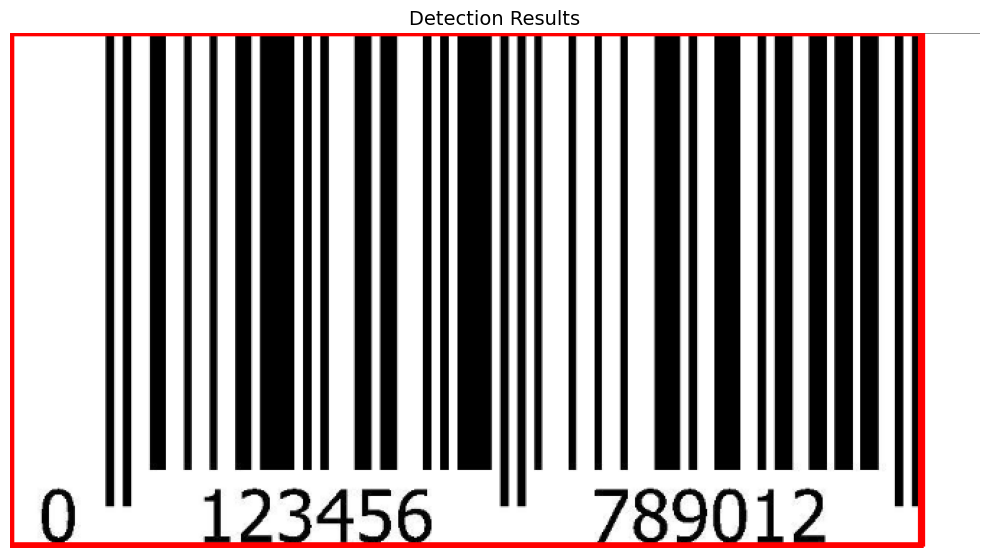


=== DETECTED CODES ===
 • [Barcode - EAN13] 0123456789012


In [77]:

IMAGE_PATH = "/content/BARCODE2.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/BARCODE3.png | Shape: (286, 650, 3)


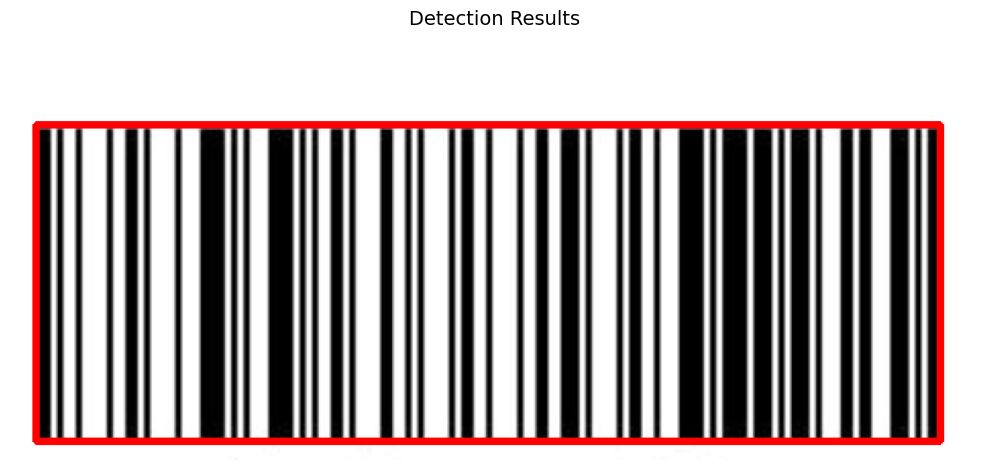


=== DETECTED CODES ===
 • [Barcode - CODE128] google.com


In [78]:

IMAGE_PATH = "/content/BARCODE3.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/QR1.png | Shape: (225, 225, 3)


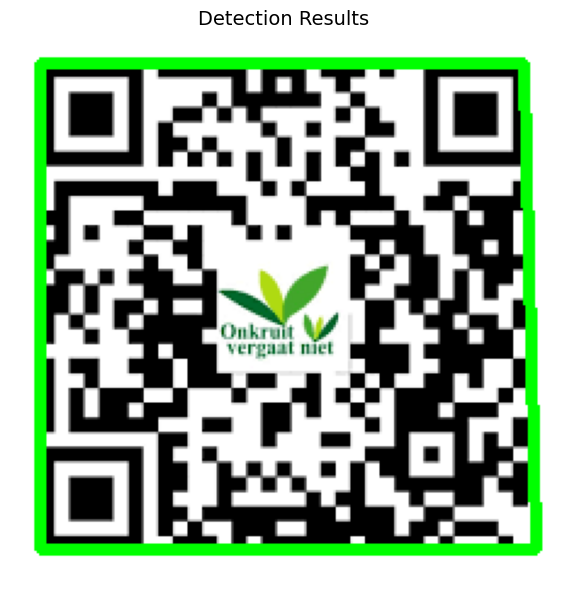


=== DETECTED CODES ===
 • [QR - Global] https://onkruitvergaatniet.nl/qr-pierson


In [74]:

IMAGE_PATH = "/content/QR1.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

Image loaded: /content/QR2.png | Shape: (1536, 1536, 3)


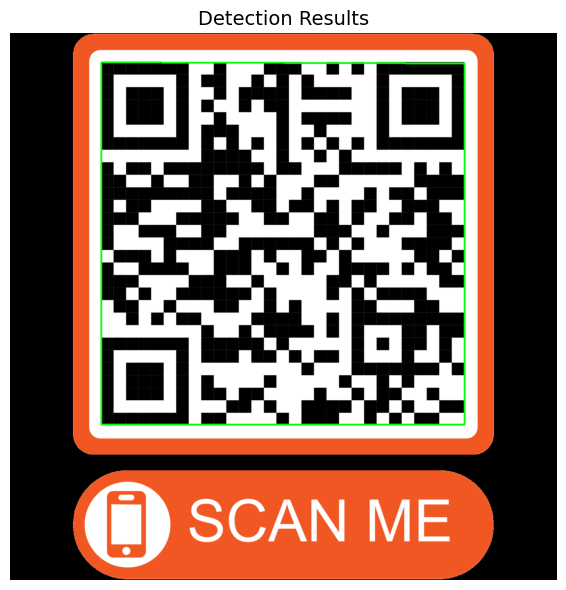


=== DETECTED CODES ===
 • [QR - Global] https://me-qr.com/FbwC4Yxw


In [75]:

IMAGE_PATH = "/content/QR2.png"
# ──────────────────────────────────────────────────────────────────────────────

if os.path.exists(IMAGE_PATH):
    output = run_pipeline(IMAGE_PATH, verbose=True)
else:
    print(f"File not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")

## 8. Interactive Widget Interface (ipywidgets)

Use the widget below to upload an image directly in the notebook and run the pipeline interactively.

In [76]:
# ── Upload widget ──────────────────────────────────────────────────────────────
uploader = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="info",
)

run_button = widgets.Button(
    description="Scan",
    button_style="success",
    icon="search",
)

output_area = widgets.Output()

def on_scan_clicked(b):
    output_area.clear_output()
    with output_area:
        if not uploader.value:
            print("Please upload an image first.")
            return

        # Decode uploaded bytes to OpenCV image
        uploaded_file = list(uploader.value.values())[0]
        img_bytes = uploaded_file["content"]
        np_arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

        if img is None:
            print("Failed to decode the uploaded image.")
            return

        print(f"Image loaded | Shape: {img.shape}")
        annotated = img.copy()
        preprocessed = preprocess_image(annotated)

        qr_global, annotated = detect_qr_global(annotated, preprocessed)
        qr_local,  annotated = detect_qr_local(annotated, preprocessed)
        barcodes,  annotated = detect_barcodes(annotated, preprocessed)

        all_results = qr_global + qr_local + barcodes

        show_image(annotated, title="Detection Results")

        print("\n=== DETECTED CODES ===")
        if all_results:
            for r in all_results:
                print(" •", r)
        else:
            print(" No QR code or barcode detected.")

run_button.on_click(on_scan_clicked)

display(widgets.VBox([uploader, run_button, output_area]))